# 🦈 Shark Cage Adventure: Riding the Waves of Data 🦈
### Business Case
**Business Opportunity:** To create a thrilling and safe shark cage diving tourism company that offers customers a high chance of seeing sharks in their natural habitat.

**Business Problem:** To guarantee customer satisfaction and safety, the company must operate in locations with a high probability of shark sightings. The dataset of attacks can serve as a proxy for where sharks are most active and what species are present.

Link for our presentation: https://prezi.com/view/jvp8HhvG9beOnT8C6Yyh/?referral_token=JD2BAElnB3FN

# --- 1. Imports ---

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Import custom functions from .py file

from shark_cleaning_functions import (
    clean_age,
    extract_year,
    clean_year_numeric,
    extract_month,
    categorize_time,
    clean_country,
    clean_state,
    map_continent, 
    simplify_species
)

# --- 2. Load Data ---

In [3]:

url = "https://docs.google.com/spreadsheets/d/16e6Czr-r-yY4feoYV6uSlNQGJC36-S3k/export?format=csv"
shark_df = pd.read_csv(url)

shark_df_cleaned = shark_df.copy()

# --- 3. Clean Columns ---

In [4]:

# list of columns to drop
columns_to_drop = [
    'pdf',
    'href formula',
    'href',
    'Case Number',
    'Case Number.1',
    'original order',
    'Unnamed: 21',
    'Unnamed: 22'
]

# use drop() with axis=1 on main DataFrame
shark_df_cleaned = shark_df_cleaned.drop(columns=columns_to_drop, axis=1)

# check the new set of columns
print("Columns left:", shark_df_cleaned.columns)

Columns left: Index(['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity',
       'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ',
       'Source'],
      dtype='object')


In [5]:
# turn columns to lowercase, removes spaces from the right and replaces middle spaces for underscores

shark_df_cleaned.columns = [col.lower().rstrip().replace(' ', '_') for col in shark_df_cleaned.columns]

In [6]:
# Clean the Age column

shark_df_cleaned.loc[:, 'age'] = shark_df_cleaned['age'].apply(clean_age)

# Now that it's a clean float column, you can calculate the mean
mean_age = shark_df_cleaned['age'].mean()

# Fill the remaining NaN values with the mean and convert to int
shark_df_cleaned.loc[:, 'age'] = shark_df_cleaned['age'].fillna(mean_age).astype(int)

/var/folders/6p/v1z8hsjn4rgggm7qtz1wkbyr0000gn/T/ipykernel_13314/2573388093.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  shark_df_cleaned.loc[:, 'age'] = shark_df_cleaned['age'].fillna(mean_age).astype(int)


In [7]:
shark_df_cleaned['age'] = shark_df_cleaned['age'].astype(int)

# Let's check the first 5 rows and the new Dtype to confirm
print(shark_df_cleaned[['age']].head())
print("\nFinal Dtype:", shark_df_cleaned['age'].dtype)

   age
0   28
1   28
2   63
3    9
4   39

Final Dtype: int64


In [8]:
# Save the value counts for the 'Country' column to a variable
country_counts = shark_df_cleaned['country'].value_counts()

# Loop through and print each country and its count
for country, count in country_counts.items():
    print(f"{country}: {count}")

total = country_counts.sum()
print(f"\nTotal country: {total}")

USA: 2570
AUSTRALIA: 1481
SOUTH AFRICA: 597
NEW ZEALAND: 144
BAHAMAS: 136
PAPUA NEW GUINEA: 136
BRAZIL: 122
MEXICO: 103
ITALY: 72
FIJI: 67
NEW CALEDONIA: 65
PHILIPPINES: 63
REUNION: 60
EGYPT: 49
CUBA: 49
MOZAMBIQUE: 46
SPAIN: 46
INDIA: 41
FRENCH POLYNESIA: 37
JAPAN: 36
CROATIA: 35
PANAMA: 32
JAMAICA: 30
SOLOMON ISLANDS: 30
IRAN: 29
Australia: 26
ENGLAND: 25
GREECE: 24
INDONESIA: 24
HONG KONG: 24
COSTA RICA: 18
ATLANTIC OCEAN: 17
PACIFIC OCEAN: 17
BERMUDA: 16
VIETNAM: 15
TONGA: 15
CANADA: 14
VANUATU: 14
SRI LANKA: 14
FRANCE: 13
MARSHALL ISLANDS: 13
TURKEY: 12
THAILAND: 12
SOUTH ATLANTIC OCEAN: 12
IRAQ: 12
ECUADOR: 11
VENEZUELA: 11
UNITED KINGDOM: 11
SENEGAL: 11
MAURITIUS: 10
COLUMBIA: 10
NEW GUINEA: 10
SAMOA: 10
KENYA: 10
CHINA: 9
SEYCHELLES: 9
TAIWAN: 9
CARIBBEAN SEA: 8
TANZANIA: 8
CHILE: 8
SIERRA LEONE: 8
SOUTH KOREA: 8
MADAGASCAR: 8
ISRAEL: 8
SCOTLAND: 8
NORTH PACIFIC OCEAN: 7
DOMINICAN REPUBLIC: 7
BELIZE: 7
INDIAN OCEAN: 7
YEMEN : 7
NEW BRITAIN: 6
BARBADOS: 6
OKINAWA: 6
SINGAPORE: 6

In [9]:
# Clean the 'country' column using the custom function
shark_df_cleaned['country'] = clean_country(shark_df_cleaned['country'])

# (Optional) You can still check the value counts to see the result
print(shark_df_cleaned['country'].value_counts().head(10))

country
usa                 2581
australia           1507
south africa         599
papua new guinea     154
new zealand          147
bahamas              141
brazil               122
france               116
mexico               107
italy                 72
Name: count, dtype: int64


In [10]:
# Create the 'continent' column by mapping the cleaned 'country' column
shark_df_cleaned['continent'] = map_continent(shark_df_cleaned['country'])

# Display the result to check
print(shark_df_cleaned[['country', 'continent']].head())

     country      continent
0        usa  north america
1  australia        oceania
2    bahamas  north america
3  australia        oceania
4        usa  north america


In [11]:
# Get the value counts for the 'country' column

country_counts = shark_df_cleaned['country'].value_counts()

# Set threshold
threshold = 20
countries_to_keep = country_counts[country_counts > threshold].index

# Filter the DataFrame to only include the countries in our 'countries_to_keep' list
shark_df_cleaned = shark_df_cleaned[shark_df_cleaned['country'].isin(countries_to_keep)]

print(f"Original number of unique countries: {shark_df_cleaned['country'].nunique()}")
print(f"Number of countries after filtering: {shark_df_cleaned['country'].nunique()}")

Original number of unique countries: 30
Number of countries after filtering: 30


In [12]:
# Clean the Year

shark_df_cleaned.loc[:, 'year_clean'] = shark_df_cleaned['date'].apply(extract_year)
shark_df_cleaned.loc[:, 'year_clean'] = shark_df_cleaned['year_clean'].apply(clean_year_numeric)

In [13]:
# Clean the 'state' column using the new function
shark_df_cleaned['state'] = clean_state(shark_df_cleaned['state'])

In [14]:
# Create a boolean mask to find all rows where 'year_clean' is still null

missing_year_mask = shark_df_cleaned['year_clean'].isna()

# Use .loc to fill the missing values in 'year_clean' with the values from the original 'Year' column
# This says: "For the rows where the mask is True, update the 'year_clean' column with the value from the 'Year' column"
shark_df_cleaned.loc[missing_year_mask, 'year_clean'] = shark_df_cleaned.loc[missing_year_mask, 'year']

# Let's check how many missing values are left
print("Missing values in 'year_clean' after filling:")
print(shark_df_cleaned['year_clean'].isna().sum())

Missing values in 'year_clean' after filling:
0


In [15]:
# Convert the 'year_clean' column from float to integer

shark_df_cleaned['year_clean'] = shark_df_cleaned['year_clean'].astype(int)

# Let's check the first 5 rows and the new Dtype to confirm
print(shark_df_cleaned[['year_clean']].head())
print("\nFinal Dtype:", shark_df_cleaned['year_clean'].dtype)

   year_clean
0        2025
1        2025
2        2025
3        2025
4        2025

Final Dtype: int64


In [16]:
# Clean the Time

shark_df_cleaned.loc[:, 'time_category'] = shark_df_cleaned['time'].apply(categorize_time)

In [17]:
# Create Quarters

shark_df_cleaned.loc[:, 'month'] = shark_df_cleaned['date'].apply(extract_month)
month_to_quarter_map = {
    'jan': 1, 'feb': 1, 'mar': 1, 'apr': 2, 'may': 2, 'jun': 2,
    'jul': 3, 'aug': 3, 'sep': 3, 'oct': 4, 'nov': 4, 'dec': 4
}
shark_df_cleaned.loc[:, 'quarter'] = shark_df_cleaned['month'].map(month_to_quarter_map)
shark_df_cleaned.loc[:, 'quarter'] = shark_df_cleaned['quarter'].fillna(0).astype(int)


In [18]:
# Check for nulls in the 'quarter' column and sum them up
missing_quarters = shark_df_cleaned['quarter'].isna().sum()

print(f"Number of rows with a missing quarter: {missing_quarters}")

Number of rows with a missing quarter: 0


In [19]:
# Reassign the result of .fillna() back to the 'quarter' column to save the changes
shark_df_cleaned['quarter'] = shark_df_cleaned['quarter'].fillna(0)

# Now that the NaNs are replaced with 0, this conversion will work
shark_df_cleaned['quarter'] = shark_df_cleaned['quarter'].astype(int)

# Check the final counts and data type
print("Final Dtype:", shark_df_cleaned['quarter'].dtype)
print("\nFinal Value Counts:")
print(shark_df_cleaned['quarter'].value_counts())

Final Dtype: int64

Final Value Counts:
quarter
3    1907
2    1375
1    1346
4    1342
0     417
Name: count, dtype: int64


In [20]:
columns_to_drop = [
  'date', 'year', 'time'
]

shark_df_cleaned = shark_df_cleaned.drop(columns=columns_to_drop, axis=1)

print("Columns left:", shark_df_cleaned.columns)

Columns left: Index(['type', 'country', 'state', 'location', 'activity', 'name', 'sex',
       'age', 'injury', 'fatal_y/n', 'species', 'source', 'continent',
       'year_clean', 'time_category', 'month', 'quarter'],
      dtype='object')


In [21]:
shark_df_final = shark_df_cleaned.drop(columns=["location","activity","name","sex","age","injury","source"])
shark_df_final.head()


,type,country,state,fatal_y/n,species,continent,year_clean,time_category,month,quarter
0,Provoked,usa,florida,N,Lemon shark 1.8 m (6ft),north america,2025,morning,aug,3
1,Unprovoked,australia,new south wales,N,5m (16.5ft) Great White,oceania,2025,morning,aug,3
2,Unprovoked,bahamas,atlantic ocean near big grand cay,N,Undetermined,north america,2025,afternoon,aug,3
3,Unprovoked,australia,new south wales,N,Suspected Great White,oceania,2025,afternoon,aug,3
4,Unprovoked,usa,carolina,N,Undetermined,north america,2025,unknown,aug,3


In [22]:
# Get the counts of attacks for each country and select the top 3
top_5_states = shark_df_final['state'].value_counts().head(5)

print("Top 5 countries with the most attacks:")
print(top_5_states)

Top 5 countries with the most attacks:
state
florida            1192
new south wales     529
queensland          353
hawaii              344
california          325
Name: count, dtype: int64


# --- Initial Data Filtering ---

# Hypothesis 1: Where are Shark Attacks Specifically Concentrated Geographically?
# Our initial hypothesis is that shark attacks are not random but are heavily concentrated in a few key coastal areas known for high beach tourism and specific marine ecosystems. This analysis will identify the top 5 states or regions globally with the most recorded incidents.

/var/folders/6p/v1z8hsjn4rgggm7qtz1wkbyr0000gn/T/ipykernel_13314/3004601561.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_states.index, y=top_5_states.values, palette='mako')


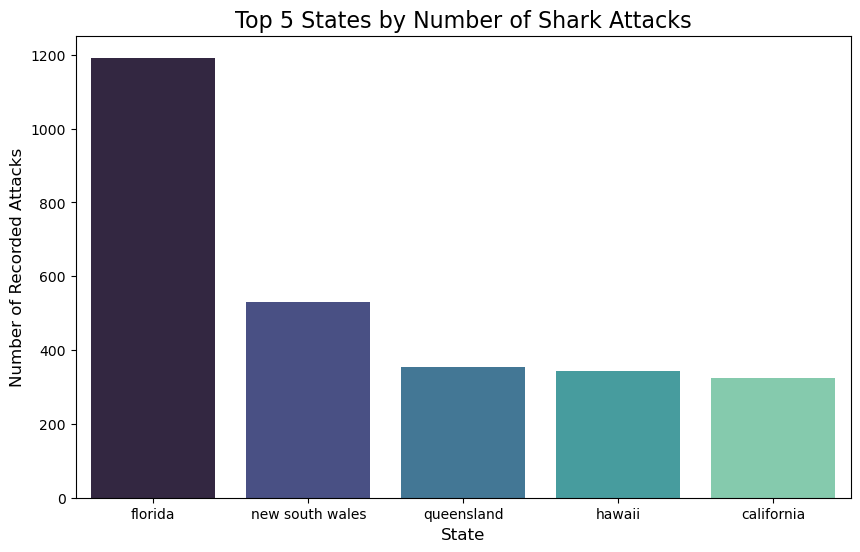

In [23]:
# Set the figure size for better readability
plt.figure(figsize=(10, 6))

# Create the bar plot
sns.barplot(x=top_5_states.index, y=top_5_states.values, palette='mako')

# Add a title and labels
plt.title('Top 5 States by Number of Shark Attacks', fontsize=16)
plt.xlabel('State', fontsize=12)
plt.ylabel('Number of Recorded Attacks', fontsize=12)

# Show the plot
plt.show()

# Observation: Florida Leads in Attack Incidents
# The bar chart clearly supports the hypothesis. **Florida** has a significantly higher number of attacks than any other location. It's also interesting to note that the top 5 includes states from both the **USA** (Florida, Hawaii, California) and **Australia** (New South Wales, Queensland), highlighting these two countries as global hotspots for shark encounters.

In [24]:
shark_df_cleaned['fatal_y/n'] = shark_df_cleaned['fatal_y/n'].str.strip().str.lower()

# Create the filtered DataFrame for non-fatal attacks in the USA
non_fatal_usa_df = shark_df_cleaned[
    (shark_df_cleaned['fatal_y/n'] == 'n') & 
    (shark_df_cleaned['country'] == 'usa')
].copy()

print(f"Created a new DataFrame with {len(non_fatal_usa_df)} non-fatal attacks in the USA.")

Created a new DataFrame with 2165 non-fatal attacks in the USA.


# Hypothesis: 
# Most shark attacks occur in the afternoon when more people are likely to be in the water. This chart will visualize the distribution of attacks by time of day to verify this.

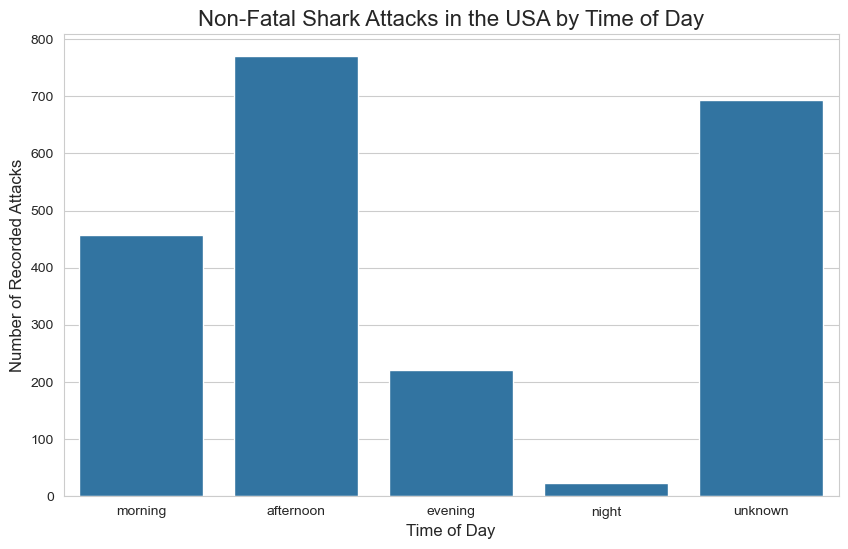

In [25]:
# Set the plot style
sns.set_style("whitegrid")

# Create a count plot for the 'time_category' column
plt.figure(figsize=(10, 6)) # Adjust figure size for better readability
sns.countplot(
    data=non_fatal_usa_df, 
    x='time_category', 
    order=['morning', 'afternoon', 'evening', 'night', 'unknown'] # Set a logical order
)

# Add titles and labels for clarity
plt.title('Non-Fatal Shark Attacks in the USA by Time of Day', fontsize=16)
plt.xlabel('Time of Day', fontsize=12)
plt.ylabel('Number of Recorded Attacks', fontsize=12)

# Show the plot
plt.show()

# The bar chart confirms the hypothesis, showing that 'afternoon' has the highest number of recorded attacks, followed by 'morning'.

In [26]:
# Create a new DataFrame that excludes the 'unknown' category
known_time_df = non_fatal_usa_df[non_fatal_usa_df['time_category'] != 'unknown'].copy()

# Check the value counts to see the result
print("Value counts for known times of day:")
print(known_time_df['time_category'].value_counts())

Value counts for known times of day:
time_category
afternoon    770
morning      458
evening      221
night         23
Name: count, dtype: int64


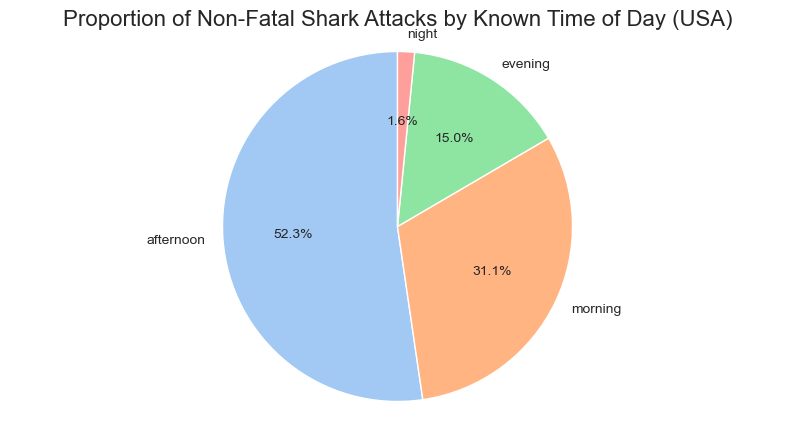

In [27]:
# Get the counts for each time category from your new DataFrame
time_counts = known_time_df['time_category'].value_counts()

# Create the pie chart
plt.figure(figsize=(10, 5)) # Adjust the figure size
plt.pie(
    time_counts, 
    labels=time_counts.index, 
    autopct='%1.1f%%', # This formats the numbers to show percentages on the chart
    startangle=90, # Rotates the start of the pie chart to the top
    colors=sns.color_palette('pastel') # Use a nice color palette
)

plt.title('Proportion of Non-Fatal Shark Attacks by Known Time of Day (USA)', fontsize=16)
plt.axis('equal') # This ensures the pie chart is a perfect circle

# Show the plot
plt.show()

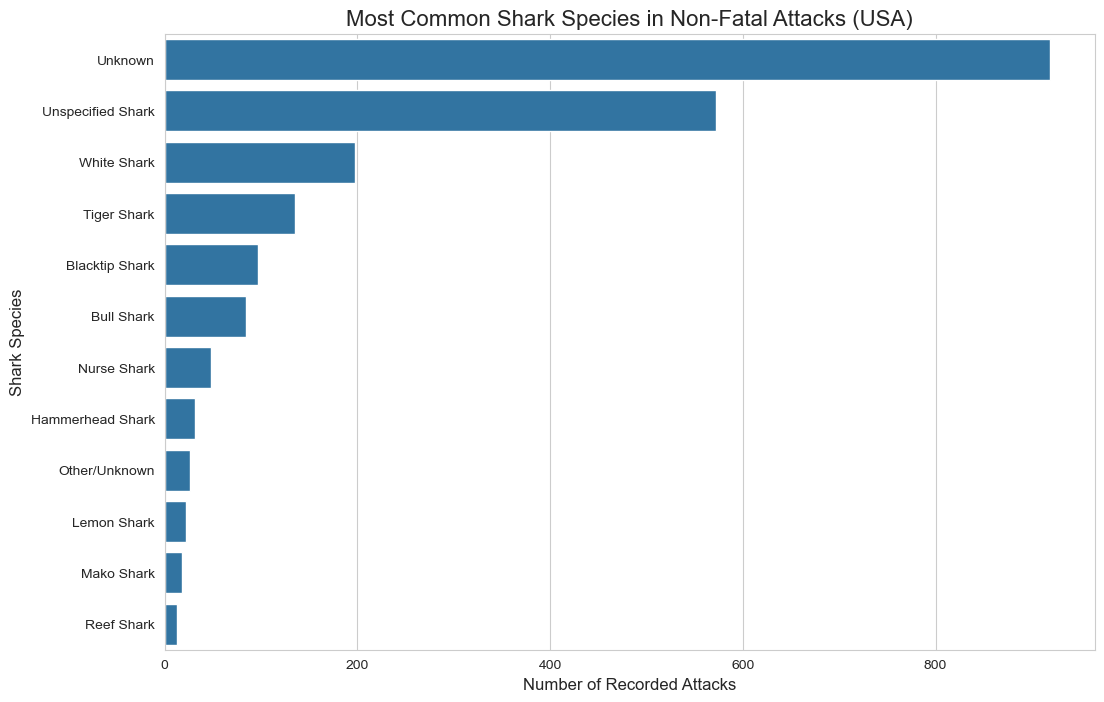

                           species                         species
0          Lemon shark 1.8 m (6ft)         Lemon shark 1.8 m (6ft)
4                     Undetermined                    Undetermined
9                      Lemon shark                     Lemon shark
10                    Undetermined                    Undetermined
12                         Unknown                         Unknown
13  Undetermined small shall shark  Undetermined small shall shark
16                Sand Tiger shark                Sand Tiger shark
17                     Small shark                     Small shark
18                      Not stated                      Not stated
19                      Bull shark                      Bull shark


In [28]:
# Apply function to the DataFrame
non_fatal_usa_df['species_simplified'] = non_fatal_usa_df['species'].apply(simplify_species)

# --- Re-create the plot ---
plt.figure(figsize=(12, 8))
sns.countplot(
    data=non_fatal_usa_df, 
    y='species_simplified',
    order=non_fatal_usa_df['species_simplified'].value_counts().index # Order by frequency
)
plt.title('Most Common Shark Species in Non-Fatal Attacks (USA)', fontsize=16)
plt.xlabel('Number of Recorded Attacks', fontsize=12)
plt.ylabel('Shark Species', fontsize=12)
plt.show()

# Check the result to see how it worked
print(non_fatal_usa_df[['species', 'species']].head(10))

In [29]:
# check for missing values in the original 'species' column of filtered DataFrame.
missing_species_count = non_fatal_usa_df['species'].isna().sum()

total_rows = len(non_fatal_usa_df)

print(f"Number of rows with missing species data from the start: {missing_species_count}")
print(f"That's about {round((missing_species_count / total_rows) * 100)}% of the non-fatal attacks in the USA.")

Number of rows with missing species data from the start: 908
That's about 42% of the non-fatal attacks in the USA.


# Hypothesis 2: Are a Few Species Responsible for Most Attacks?
# Now focusing on non-fatal attacks within the USA, the next hypothesis is that a small number of well-known shark species (like White Sharks) are responsible for the majority of identifiable incidents. This chart visualizes the frequency of attacks by identified species.

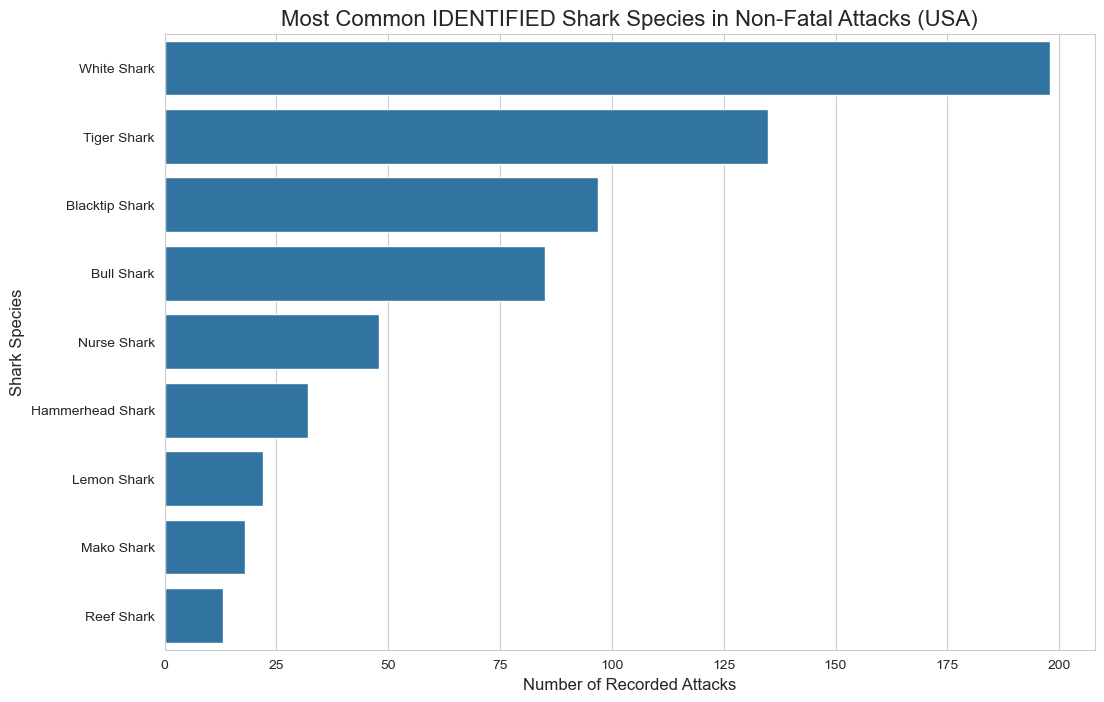

In [30]:
# Create a new DataFrame for plotting that excludes the 'Unknown' categories
plot_df = non_fatal_usa_df[
    ~non_fatal_usa_df['species_simplified'].isin(['Unknown', 'Other/Unknown', 'Unspecified Shark'])
].copy()

# --- Re-create the plot from this new filtered DataFrame ---
plt.figure(figsize=(12, 8))
sns.countplot(
    data=plot_df,
    y='species_simplified',
    order=plot_df['species_simplified'].value_counts().index # Order by frequency
)
plt.title('Most Common IDENTIFIED Shark Species in Non-Fatal Attacks (USA)', fontsize=16)
plt.xlabel('Number of Recorded Attacks', fontsize=12)
plt.ylabel('Shark Species', fontsize=12)
plt.show()

# Observation: White Sharks are the Most Commonly Identified
# As hypothesized, the **White Shark** is the most frequently identified species in non-fatal attacks in the USA. However, a major takeaway is the large number of attacks where the species was **"Unknown"** or **"Unspecified."** This highlights a significant limitation in the dataset and suggests that while we can identify a primary aggressor, many incidents lack complete data.

In [31]:
# check for missing values in the original 'species' column of filtered DataFrame.
missing_species_count = non_fatal_usa_df['species'].isna().sum()

total_rows = len(non_fatal_usa_df)

print(f"Number of rows with missing species data from the start: {missing_species_count}")
print(f"That's about {round((missing_species_count / total_rows) * 100)}% of the non-fatal attacks in the USA.")

Number of rows with missing species data from the start: 908
That's about 42% of the non-fatal attacks in the USA.


In [32]:
# Create a new DataFrame seasonal analysis, filtering out the '0' quarter
seasonal_df = non_fatal_usa_df[non_fatal_usa_df['quarter'] != 0].copy()

# Hypothesis 3: Are Shark Attacks Seasonal?

# The final hypothesis is that shark attacks follow a seasonal pattern, peaking during the summer months. In the USA, this corresponds to the second and third quarters (April-September), when warmer weather and school holidays lead to more people participating in ocean activities like swimming and surfing. This chart examines the number of attacks per quarter to see if such a trend exists.

/var/folders/6p/v1z8hsjn4rgggm7qtz1wkbyr0000gn/T/ipykernel_13314/3941454470.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


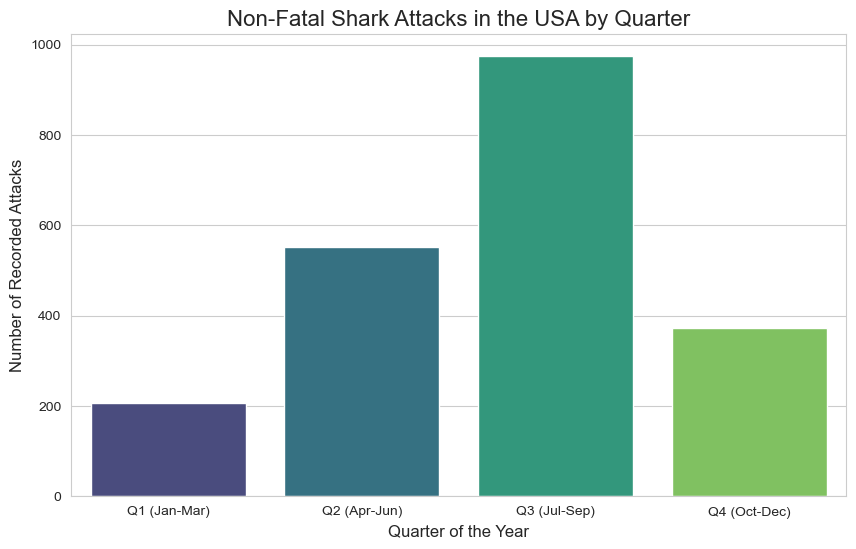

In [33]:
# Set the plot style
sns.set_style("whitegrid")

# Create a count plot for the 'quarter' column
plt.figure(figsize=(10, 6))
sns.countplot(
    data=seasonal_df, 
    x='quarter',
    palette='viridis' # Using a different color palette for variety
)

# Add titles and labels for clarity
plt.title('Non-Fatal Shark Attacks in the USA by Quarter', fontsize=16)
plt.xlabel('Quarter of the Year', fontsize=12)
plt.ylabel('Number of Recorded Attacks', fontsize=12)

# Improve x-axis labels to be more descriptive
plt.xticks(ticks=[0, 1, 2, 3], labels=['Q1 (Jan-Mar)', 'Q2 (Apr-Jun)', 'Q3 (Jul-Sep)', 'Q4 (Oct-Dec)'])

# Show the plot
plt.show()

# Observation: Attacks Peak in the Third Quarter (Summer)

# The data strongly confirms the seasonal hypothesis. The third quarter (July-September) shows the highest frequency of non-fatal shark attacks in the USA, aligning perfectly with the peak summer season. The second quarter (April-June) also has a high number of incidents. In contrast, the attack numbers drop significantly during the colder first and fourth quarters. This pattern is crucial for understanding seasonal risk and implementing safety measures during peak months.

### **Save a copy** 👇 

In [ ]:
shark_df_final.to_csv("shark_df_final.csv", index=False)